In [1]:
!pip install seaborn

In [2]:
%matplotlib inline

In [3]:
import os
import glob
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from collections import Counter
from sklearn.metrics import confusion_matrix, f1_score
import matplotlib
#matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import time

In [4]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


## Configuration

In [15]:
import os
import random
import numpy as np
import torch
from google.colab import drive

# =========================
# Mount Google Drive
# =========================

drive.mount('/content/drive')

# =========================
# Config for Colab + your dataset
# =========================

CFG = {
    # Paths
    "dataset_dir": "/content/drive/MyDrive/ДЗ_Дьяченко/term_2/task_2_dgcnn/dataset",
    "output_dir": "/content/drive/MyDrive/ДЗ_Дьяченко/term_2/task_2_dgcnn/output",

    # Dataset
    "file_pattern": "valve_*_lidar_classes.ply",
    "num_classes": 14,

    # Sampling
    # У тебя файлы имеют больше 8192 точек, но для Colab 4096 безопаснее
    "num_points": 4096,

    # Training
    "batch_size": 16,
    "epochs": 20,
    "lr": 1e-3,
    "weight_decay": 1e-4,
    "scheduler_step": 20,
    "scheduler_gamma": 0.5,
    "patience": 25,

    # DGCNN
    "k": 20,
    "emb_dims": 1024,
    "dropout": 0.5,

    # Split ratios
    "train_ratio": 0.70,
    "val_ratio": 0.15,
    "test_ratio": 0.15,

    # Reproducibility
    "seed": 42,

    # Workers
    # Для Colab часто стабильнее 2 или 4, чем 8
    "num_workers": 2,

    # Device
    "use_cuda": True,
}


# =========================
# Reproducibility
# =========================

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything(CFG["seed"])


# =========================
# Create output dir
# =========================

os.makedirs(CFG["output_dir"], exist_ok=True)


# =========================
# Device
# =========================

DEVICE = torch.device(
    "cuda" if CFG["use_cuda"] and torch.cuda.is_available() else "cpu"
)

print(f"Device: {DEVICE}")

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


# =========================
# Check dataset path
# =========================

print("Dataset dir:", CFG["dataset_dir"])
print("Output dir:", CFG["output_dir"])

if not os.path.exists(CFG["dataset_dir"]):
    raise FileNotFoundError(f"Dataset folder not found: {CFG['dataset_dir']}")

print("Dataset folder exists.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda
GPU: Tesla T4
Dataset dir: /content/drive/MyDrive/ДЗ_Дьяченко/term_2/task_2_dgcnn/dataset
Output dir: /content/drive/MyDrive/ДЗ_Дьяченко/term_2/task_2_dgcnn/output
Dataset folder exists.


## PLY loader

In [16]:
def load_ply(filepath):
    """
    Load ASCII .ply with x, y, z, scalar_Label.
    Returns:
        points  – (N, 3) float32
        labels  – (N,)   int64
    """
    with open(filepath, "r") as f:
        line = f.readline().strip()
        assert line == "ply", f"Not a PLY file: {filepath}"

        num_vertices = None
        while True:
            line = f.readline().strip()
            if line.startswith("element vertex"):
                num_vertices = int(line.split()[-1])
            if line == "end_header":
                break

        assert num_vertices is not None, f"Could not parse vertex count in {filepath}"

        points = np.empty((num_vertices, 3), dtype=np.float32)
        labels = np.empty(num_vertices, dtype=np.int64)

        for i in range(num_vertices):
            parts = f.readline().strip().split()
            points[i, 0] = float(parts[0])
            points[i, 1] = float(parts[1])
            points[i, 2] = float(parts[2])
            labels[i] = int(parts[3])

    return points, labels

## Dataset investigation

In [17]:
def investigate_dataset(file_list):
    """Scan all files to find class set, counts, and per-file point stats."""
    global_counts = Counter()
    point_counts = []

    for fp in file_list:
        _, labels = load_ply(fp)
        point_counts.append(len(labels))
        for lbl in labels:
            global_counts[lbl] += 1

    classes = sorted(global_counts.keys())
    num_classes = len(classes)
    total_points = sum(global_counts.values())

    print("=" * 60)
    print("DATASET INVESTIGATION")
    print("=" * 60)
    print(f"Files           : {len(file_list)}")
    print(f"Points/file     : min={min(point_counts)}, max={max(point_counts)}, "
          f"mean={np.mean(point_counts):.0f}")
    print(f"Classes found   : {classes}")
    print(f"Num classes     : {num_classes}")
    print(f"Total points    : {total_points}")
    print("-" * 60)
    print(f"{'Class':>7}  {'Count':>12}  {'Fraction':>10}")
    print("-" * 60)
    for c in classes:
        print(f"{c:>7}  {global_counts[c]:>12,}  {global_counts[c]/total_points:>10.4f}")
    print("=" * 60)

    # Compute inverse-frequency weights (capped to avoid extreme values)
    counts_arr = np.array([global_counts[c] for c in classes], dtype=np.float64)
    inv_freq = total_points / (num_classes * counts_arr)
    # Gentle cap: median-normalize then clip
    inv_freq = inv_freq / np.median(inv_freq)
    inv_freq = np.clip(inv_freq, 0.5, 5.0)
    print(f"CE weights      : {np.round(inv_freq, 4).tolist()}")

    return num_classes, classes, inv_freq

## Dataset preprocessing

In [18]:
class PointCloudDataset(Dataset):
    """
    Loads PLY files, normalises, samples fixed number of points.
    Augmentation applied only when `augment=True`.
    """

    def __init__(self, file_list, num_points=4096, augment=False):
        super().__init__()
        self.file_list = file_list
        self.num_points = num_points
        self.augment = augment
        # Pre-load everything into RAM (500 files * ~15k pts * 4 floats ≈ tiny)
        self.data = []
        for fp in file_list:
            pts, lbl = load_ply(fp)
            self.data.append((pts, lbl))

    def __len__(self):
        return len(self.data)

    def _normalize(self, points):
        """Center then scale to unit sphere."""
        centroid = points.mean(axis=0)
        points = points - centroid
        max_dist = np.max(np.linalg.norm(points, axis=1))
        if max_dist > 0:
            points = points / max_dist
        return points

    def _augment(self, points):
        """Shuffle, rotate, scale, jitter."""
        # 1. Shuffle point order
        idx = np.random.permutation(len(points))
        points = points[idx]
        # (labels will be shuffled with the same idx in __getitem__)
        # We return idx so caller can apply to labels too
        return points, idx

    @staticmethod
    def _apply_augment_transforms(points):
        """Rotation around Y (up) axis, random scale, jitter.  Applied AFTER sampling."""
        # Random rotation around all 3 axes (small for X,Z; full for Y)
        angle_y = np.random.uniform(0, 2 * np.pi)
        angle_x = np.random.uniform(-np.pi / 18, np.pi / 18)  # ±10°
        angle_z = np.random.uniform(-np.pi / 18, np.pi / 18)

        Ry = np.array([
            [np.cos(angle_y), 0, np.sin(angle_y)],
            [0, 1, 0],
            [-np.sin(angle_y), 0, np.cos(angle_y)]
        ], dtype=np.float32)

        Rx = np.array([
            [1, 0, 0],
            [0, np.cos(angle_x), -np.sin(angle_x)],
            [0, np.sin(angle_x), np.cos(angle_x)]
        ], dtype=np.float32)

        Rz = np.array([
            [np.cos(angle_z), -np.sin(angle_z), 0],
            [np.sin(angle_z), np.cos(angle_z), 0],
            [0, 0, 1]
        ], dtype=np.float32)

        R = Rz @ Ry @ Rx
        points = points @ R.T

        # Random scale
        scale = np.random.uniform(0.8, 1.2)
        points = points * scale

        # Jitter
        jitter = np.random.normal(0, 0.01, size=points.shape).astype(np.float32)
        jitter = np.clip(jitter, -0.05, 0.05)
        points = points + jitter

        return points

    def __getitem__(self, idx):
        points, labels = self.data[idx]
        points = points.copy()
        labels = labels.copy()

        # Normalize
        points = self._normalize(points)

        N = len(points)
        if N >= self.num_points:
            choice = np.random.choice(N, self.num_points, replace=False)
        else:
            choice = np.random.choice(N, self.num_points, replace=True)

        points = points[choice]
        labels = labels[choice]

        if self.augment:
            # Shuffle
            perm = np.random.permutation(self.num_points)
            points = points[perm]
            labels = labels[perm]
            # Geometric augmentations
            points = self._apply_augment_transforms(points)

        # (num_points, 3) → (3, num_points) for Conv1d-based model
        points = torch.from_numpy(points).float().permute(1, 0)   # (3, N)
        labels = torch.from_numpy(labels).long()                   # (N,)
        return points, labels

## DGCNN

In [19]:
def knn(x, k):
    """
    x : (B, C, N)
    returns idx : (B, N, k)  — indices of k nearest neighbours
    """
    inner = -2 * torch.matmul(x.transpose(2, 1), x)       # (B, N, N)
    xx = torch.sum(x ** 2, dim=1, keepdim=True)            # (B, 1, N)
    pairwise_dist = -xx - inner - xx.transpose(2, 1)       # (B, N, N) (negative dist)
    idx = pairwise_dist.topk(k=k, dim=-1)[1]               # (B, N, k)
    return idx


def get_graph_feature(x, k=20, idx=None):
    """
    x : (B, C, N)
    returns: (B, 2*C, N, k)
    """
    B, C, N = x.size()
    if idx is None:
        idx = knn(x, k=k)                                  # (B, N, k)

    idx_base = torch.arange(0, B, device=x.device).view(-1, 1, 1) * N
    idx = idx + idx_base                                    # (B, N, k)
    idx = idx.view(-1)                                      # (B*N*k,)

    x_t = x.transpose(2, 1).contiguous()                   # (B, N, C)
    neighbours = x_t.view(B * N, -1)[idx].view(B, N, k, C) # (B, N, k, C)
    x_rep = x_t.view(B, N, 1, C).expand(-1, -1, k, -1)    # (B, N, k, C)

    edge_feature = torch.cat([neighbours - x_rep, x_rep], dim=3)  # (B, N, k, 2C)
    edge_feature = edge_feature.permute(0, 3, 1, 2).contiguous()  # (B, 2C, N, k)
    return edge_feature


class EdgeConv(nn.Module):
    def __init__(self, in_channels, out_channels, k):
        super().__init__()
        self.k = k
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels * 2, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(0.2, inplace=True),
        )

    def forward(self, x):
        """x: (B, C_in, N) → (B, C_out, N)"""
        feat = get_graph_feature(x, k=self.k)      # (B, 2*C_in, N, k)
        feat = self.conv(feat)                       # (B, C_out, N, k)
        feat = feat.max(dim=-1)[0]                   # (B, C_out, N)
        return feat


class DGCNN_Seg(nn.Module):
    """DGCNN for per-point semantic segmentation."""

    def __init__(self, num_classes=9, k=20, emb_dims=1024, dropout=0.5):
        super().__init__()
        self.k = k

        # EdgeConv blocks
        self.ec1 = EdgeConv(3, 64, k)
        self.ec2 = EdgeConv(64, 64, k)
        self.ec3 = EdgeConv(64, 128, k)
        self.ec4 = EdgeConv(128, 256, k)

        # Bottleneck 1×1 conv on concatenated local features
        self.conv_bottle = nn.Sequential(
            nn.Conv1d(64 + 64 + 128 + 256, emb_dims, 1, bias=False),
            nn.BatchNorm1d(emb_dims),
            nn.LeakyReLU(0.2, inplace=True),
        )

        # Segmentation head — per-point MLP
        # Input: emb_dims (global) + 64+64+128+256 (local concat) = emb_dims + 512
        seg_in = emb_dims + 64 + 64 + 128 + 256
        self.seg_head = nn.Sequential(
            nn.Conv1d(seg_in, 512, 1, bias=False),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(dropout),

            nn.Conv1d(512, 256, 1, bias=False),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(dropout),

            nn.Conv1d(256, 128, 1, bias=False),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv1d(128, num_classes, 1),
        )

    def forward(self, x):
        """
        x : (B, 3, N)
        returns : (B, num_classes, N)
        """
        B, _, N = x.size()

        x1 = self.ec1(x)       # (B, 64, N)
        x2 = self.ec2(x1)      # (B, 64, N)
        x3 = self.ec3(x2)      # (B, 128, N)
        x4 = self.ec4(x3)      # (B, 256, N)

        local_cat = torch.cat([x1, x2, x3, x4], dim=1)    # (B, 512, N)
        global_feat = self.conv_bottle(local_cat)           # (B, emb_dims, N)
        global_feat = global_feat.max(dim=-1, keepdim=True)[0]  # (B, emb_dims, 1)
        global_feat = global_feat.expand(-1, -1, N)              # (B, emb_dims, N)

        combined = torch.cat([global_feat, local_cat], dim=1)    # (B, emb_dims+512, N)
        logits = self.seg_head(combined)                          # (B, C, N)
        return logits

## Metrics

In [20]:
def compute_metrics(all_preds, all_labels, num_classes):
    """
    all_preds  : 1-D numpy int array
    all_labels : 1-D numpy int array
    Returns dict with OA, mIoU, per-class IoU, macro F1, confusion matrix.
    """
    cm = confusion_matrix(all_labels, all_preds, labels=list(range(num_classes)))

    # Overall accuracy
    oa = np.trace(cm) / (cm.sum() + 1e-12)

    # Per-class IoU
    per_class_iou = np.zeros(num_classes)
    for c in range(num_classes):
        tp = cm[c, c]
        fp = cm[:, c].sum() - tp
        fn = cm[c, :].sum() - tp
        per_class_iou[c] = tp / (tp + fp + fn + 1e-12)

    miou = per_class_iou.mean()

    # F1 (macro)
    f1_macro = f1_score(all_labels, all_preds, labels=list(range(num_classes)),
                        average="macro", zero_division=0)

    # Per-class F1
    f1_per = f1_score(all_labels, all_preds, labels=list(range(num_classes)),
                      average=None, zero_division=0)

    return {
        "oa": oa,
        "miou": miou,
        "per_class_iou": per_class_iou,
        "f1_macro": f1_macro,
        "f1_per_class": f1_per,
        "confusion_matrix": cm,
    }


## Training and evaluating

In [21]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_points = 0

    for points, labels in loader:
        points = points.to(device)          # (B, 3, N)
        labels = labels.to(device)          # (B, N)

        optimizer.zero_grad()
        logits = model(points)              # (B, C, N)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        preds = logits.argmax(dim=1)        # (B, N)
        total_loss += loss.item() * points.size(0)
        total_correct += (preds == labels).sum().item()
        total_points += labels.numel()

    avg_loss = total_loss / len(loader.dataset)
    avg_acc = total_correct / total_points
    return avg_loss, avg_acc


@torch.no_grad()
def evaluate(model, loader, criterion, device, num_classes):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_labels = []

    for points, labels in loader:
        points = points.to(device)
        labels = labels.to(device)

        logits = model(points)
        loss = criterion(logits, labels)
        total_loss += loss.item() * points.size(0)

        preds = logits.argmax(dim=1)
        all_preds.append(preds.cpu().numpy().reshape(-1))
        all_labels.append(labels.cpu().numpy().reshape(-1))

    avg_loss = total_loss / len(loader.dataset)
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    metrics = compute_metrics(all_preds, all_labels, num_classes)
    metrics["loss"] = avg_loss
    return metrics

## Plotting utilities

In [22]:
def plot_training_curves(history, output_dir):
    epochs = range(1, len(history["train_loss"]) + 1)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Loss
    axes[0, 0].plot(epochs, history["train_loss"], label="Train")
    axes[0, 0].plot(epochs, history["val_loss"], label="Val")
    axes[0, 0].set_title("Loss")
    axes[0, 0].set_xlabel("Epoch")
    axes[0, 0].legend()
    axes[0, 0].grid(True)

    # Accuracy
    axes[0, 1].plot(epochs, history["train_acc"], label="Train")
    axes[0, 1].plot(epochs, history["val_oa"], label="Val OA")
    axes[0, 1].set_title("Overall Accuracy")
    axes[0, 1].set_xlabel("Epoch")
    axes[0, 1].legend()
    axes[0, 1].grid(True)

    # mIoU
    axes[1, 0].plot(epochs, history["val_miou"], label="Val mIoU", color="green")
    axes[1, 0].set_title("Mean IoU (Validation)")
    axes[1, 0].set_xlabel("Epoch")
    axes[1, 0].legend()
    axes[1, 0].grid(True)

    # F1
    axes[1, 1].plot(epochs, history["val_f1"], label="Val F1 (macro)", color="orange")
    axes[1, 1].set_title("F1-score (macro, Validation)")
    axes[1, 1].set_xlabel("Epoch")
    axes[1, 1].legend()
    axes[1, 1].grid(True)

    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "training_curves.png"), dpi=150)
    plt.show()
    plt.close()
    print(f"[✔] Training curves saved.")


def plot_confusion_matrix(cm, classes, output_dir, tag="test"):
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=[f"Class {c}" for c in classes],
                yticklabels=[f"Class {c}" for c in classes], ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"Confusion Matrix ({tag})")
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f"confusion_matrix_{tag}.png"), dpi=150)
    plt.show()
    plt.close()
    print(f"[✔] Confusion matrix ({tag}) saved.")


def plot_per_class_iou(per_class_iou, classes, output_dir, tag="test"):
    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar([f"Class {c}" for c in classes], per_class_iou, color="steelblue")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("IoU")
    ax.set_title(f"Per-class IoU ({tag})")
    for bar, val in zip(bars, per_class_iou):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f"per_class_iou_{tag}.png"), dpi=150)
    plt.show()
    plt.close()
    print(f"[✔] Per-class IoU bar chart ({tag}) saved.")

## Inference

In [23]:
# Distinct colours per class (up to 10)
CLASS_COLORS = np.array([
    [255,   0,   0],   # 0 - red
    [  0, 255,   0],   # 1 - green
    [  0,   0, 255],   # 2 - blue
    [255, 255,   0],   # 3 - yellow
    [255,   0, 255],   # 4 - magenta
    [  0, 255, 255],   # 5 - cyan
    [255, 128,   0],   # 6 - orange
    [128,   0, 255],   # 7 - purple
    [  0, 128, 128],   # 8 - teal
    [128, 128, 128],   # 9 - grey
], dtype=np.uint8)


@torch.no_grad()
def infer_full_cloud(model, filepath, device, num_classes, num_points=4096):
    """
    Run inference on ALL points in the file using a sliding-window / voting approach.
    Each point gets voted on; final label = majority vote.
    """
    model.eval()
    points_full, labels_full = load_ply(filepath)
    N = len(points_full)

    # Normalise the same way as training
    centroid = points_full.mean(axis=0)
    pts_norm = points_full - centroid
    max_dist = np.max(np.linalg.norm(pts_norm, axis=1))
    if max_dist > 0:
        pts_norm = pts_norm / max_dist

    # Vote accumulators
    vote_counts = np.zeros((N, num_classes), dtype=np.float64)

    # Number of voting rounds (ensure good coverage)
    n_votes = max(10, (N // num_points) * 5)

    for _ in range(n_votes):
        if N >= num_points:
            choice = np.random.choice(N, num_points, replace=False)
        else:
            choice = np.random.choice(N, num_points, replace=True)

        batch = torch.from_numpy(pts_norm[choice]).float().permute(1, 0).unsqueeze(0).to(device)
        logits = model(batch)                    # (1, C, num_points)
        probs = F.softmax(logits, dim=1)         # (1, C, num_points)
        probs = probs.squeeze(0).cpu().numpy().T # (num_points, C)

        for j, idx in enumerate(choice):
            vote_counts[idx] += probs[j]

    preds_full = vote_counts.argmax(axis=1)
    return points_full, labels_full, preds_full


def save_coloured_ply(filepath, points, labels, colors_lut):
    """Save a PLY with RGB colours based on class labels."""
    N = len(points)
    colors = colors_lut[labels % len(colors_lut)]
    with open(filepath, "w") as f:
        f.write("ply\n")
        f.write("format ascii 1.0\n")
        f.write(f"element vertex {N}\n")
        f.write("property float x\n")
        f.write("property float y\n")
        f.write("property float z\n")
        f.write("property uchar red\n")
        f.write("property uchar green\n")
        f.write("property uchar blue\n")
        f.write("property int scalar_Label\n")
        f.write("end_header\n")
        for i in range(N):
            f.write(f"{points[i,0]:.6f} {points[i,1]:.6f} {points[i,2]:.6f} "
                    f"{colors[i,0]} {colors[i,1]} {colors[i,2]} {labels[i]}\n")

## Main

Found 509 PLY files.
[!] Held-out file (not used in training): valve_0328_lidar_classes.ply
DATASET INVESTIGATION
Files           : 508
Points/file     : min=5526, max=19117, mean=6062
Classes found   : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13)]
Num classes     : 14
Total points    : 3079693
------------------------------------------------------------
  Class         Count    Fraction
------------------------------------------------------------
      0       506,314      0.1644
      1       144,736      0.0470
      2       138,124      0.0448
      3       193,917      0.0630
      4       163,670      0.0531
      5        82,354      0.0267
      6       407,876      0.1324
      7       117,711      0.0382
      8        98,912      0.0321
      9       133,921      0.0435
     10       132,558      0.0430
     11       190,941      0.0620

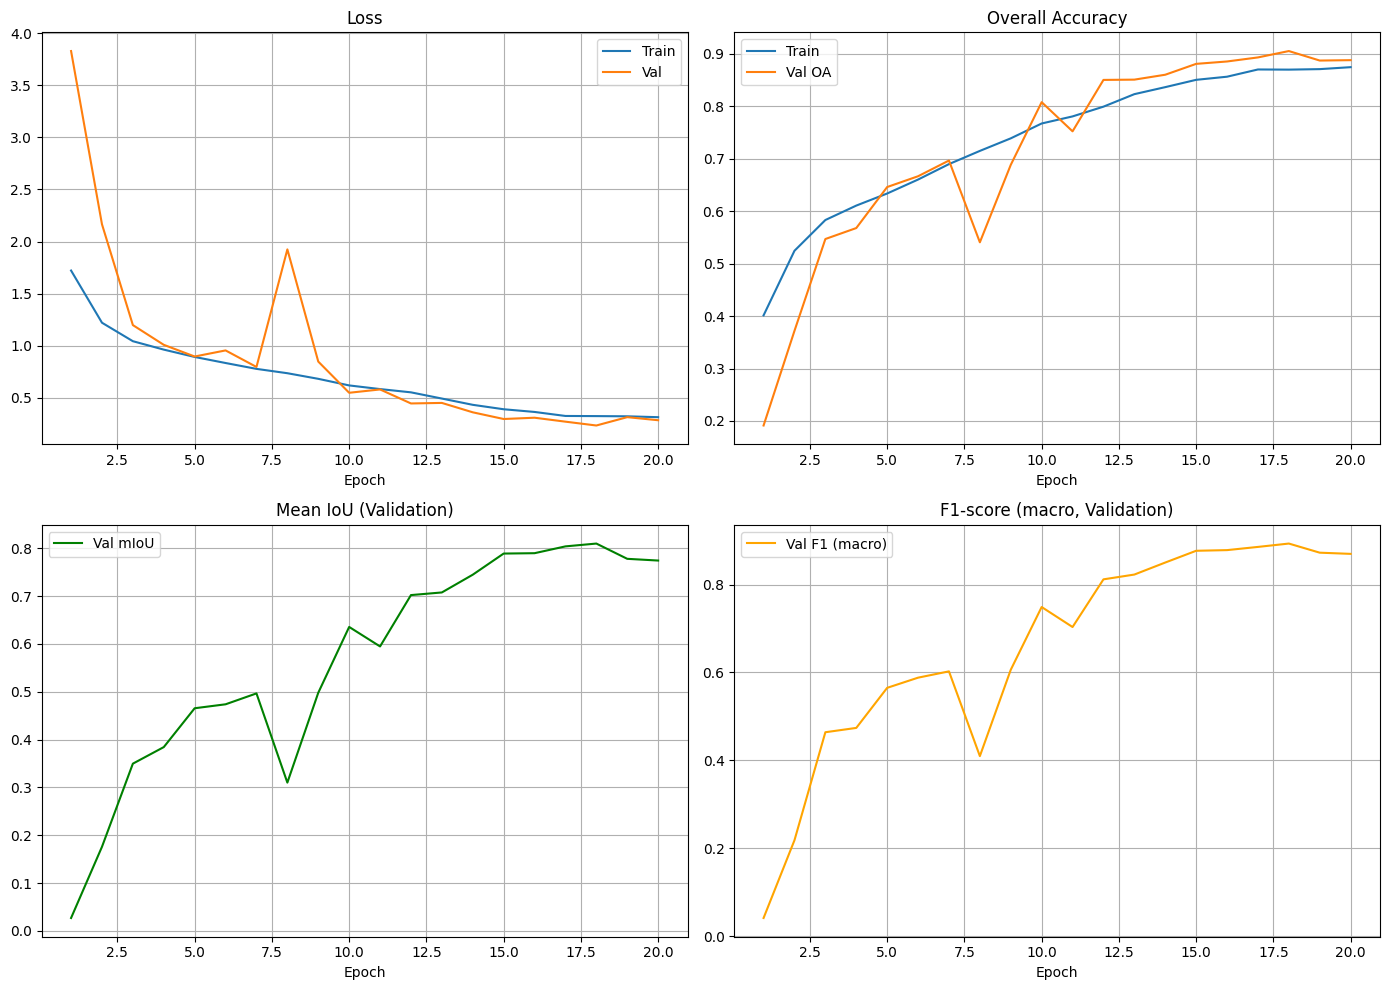

[✔] Training curves saved.

TEST SET EVALUATION (best model)
  Overall Accuracy : 0.9065
  Mean IoU         : 0.8139
  F1 (macro)       : 0.8955
  Per-class IoU    :
      Class 0 : IoU=0.9801  F1=0.9899
      Class 1 : IoU=0.7475  F1=0.8555
      Class 2 : IoU=0.7211  F1=0.8379
      Class 3 : IoU=0.8925  F1=0.9432
      Class 4 : IoU=0.8938  F1=0.9439
      Class 5 : IoU=0.7802  F1=0.8765
      Class 6 : IoU=0.8809  F1=0.9367
      Class 7 : IoU=0.7888  F1=0.8819
      Class 8 : IoU=0.8414  F1=0.9139
      Class 9 : IoU=0.7321  F1=0.8453
      Class 10 : IoU=0.8517  F1=0.9199
      Class 11 : IoU=0.7972  F1=0.8872
      Class 12 : IoU=0.7272  F1=0.8421
      Class 13 : IoU=0.7599  F1=0.8636
[✔] Test metrics saved to test_metrics.json


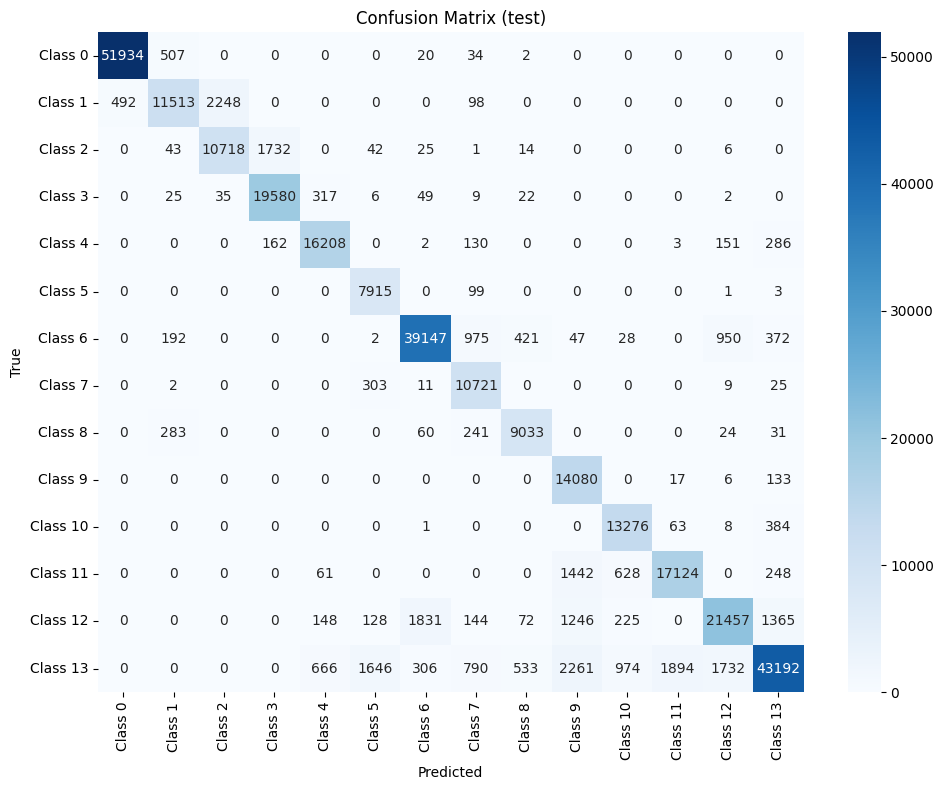

[✔] Confusion matrix (test) saved.


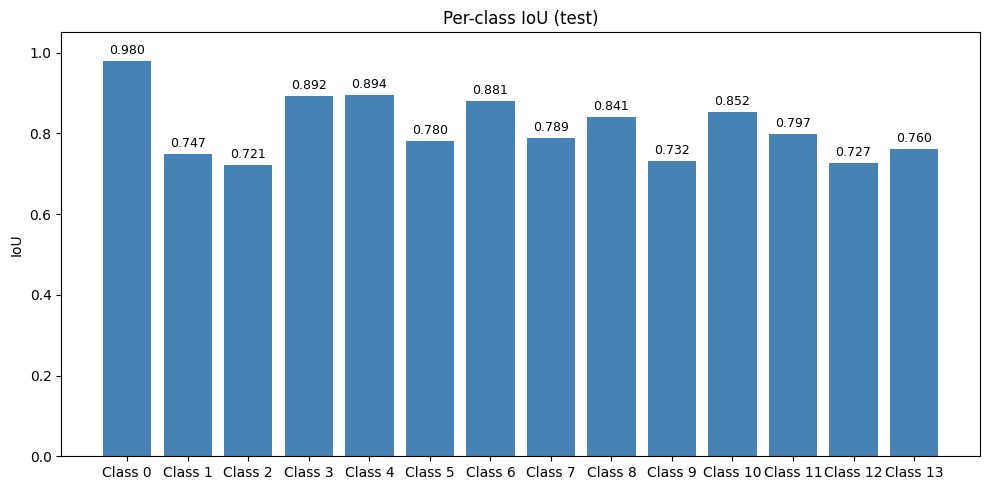

[✔] Per-class IoU bar chart (test) saved.

INFERENCE ON HELD-OUT FILE: valve_0328_lidar_classes.ply
  Overall Accuracy : 0.9266
  Mean IoU         : 0.8464
  F1 (macro)       : 0.9142
  [✔] Ground truth saved: /content/drive/MyDrive/ДЗ_Дьяченко/term_2/task_2_dgcnn/output/holdout_ground_truth.ply
  [✔] Predictions  saved: /content/drive/MyDrive/ДЗ_Дьяченко/term_2/task_2_dgcnn/output/holdout_prediction.ply
  [✔] Error map    saved: /content/drive/MyDrive/ДЗ_Дьяченко/term_2/task_2_dgcnn/output/holdout_error_map.ply


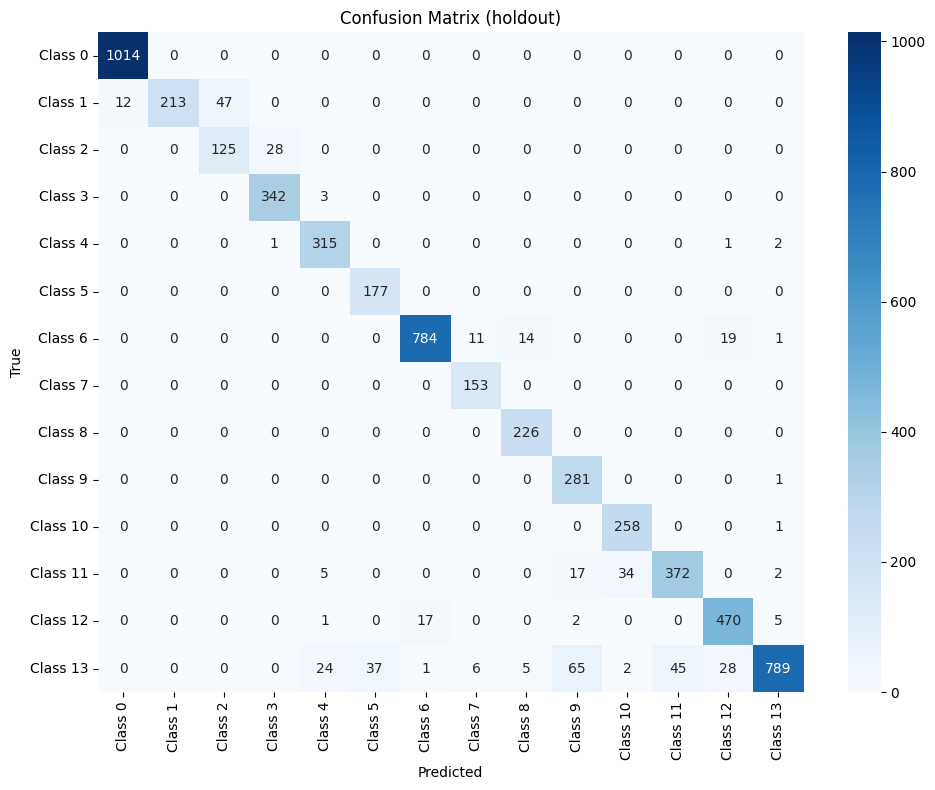

[✔] Confusion matrix (holdout) saved.

ALL DONE


In [24]:
def main():
    # ── Gather files ──────────────────────────────────────────────────────────
    all_files = sorted(glob.glob(os.path.join(CFG["dataset_dir"], "*.ply")))
    assert len(all_files) > 0, f"No .ply files found in {CFG['dataset_dir']}"
    print(f"Found {len(all_files)} PLY files.")

    # ── Hold out ONE file for final demo inference ────────────────────────────
    random.shuffle(all_files)
    holdout_file = all_files.pop()
    print(f"[!] Held-out file (not used in training): {os.path.basename(holdout_file)}")

    # ── Investigate dataset ───────────────────────────────────────────────────
    num_classes, classes, ce_weights = investigate_dataset(all_files)

    # ── Split by objects ──────────────────────────────────────────────────────
    n = len(all_files)
    n_train = int(n * CFG["train_ratio"])
    n_val = int(n * CFG["val_ratio"])
    n_test = n - n_train - n_val

    train_files = all_files[:n_train]
    val_files = all_files[n_train:n_train + n_val]
    test_files = all_files[n_train + n_val:]
    print(f"Split: train={len(train_files)}, val={len(val_files)}, test={len(test_files)}")

    # ── Datasets & Loaders ────────────────────────────────────────────────────
    train_ds = PointCloudDataset(train_files, num_points=CFG["num_points"], augment=True)
    val_ds = PointCloudDataset(val_files, num_points=CFG["num_points"], augment=False)
    test_ds = PointCloudDataset(test_files, num_points=CFG["num_points"], augment=False)

    train_loader = DataLoader(train_ds, batch_size=CFG["batch_size"], shuffle=True,
                              num_workers=CFG["num_workers"], pin_memory=True, drop_last=True)
    val_loader = DataLoader(val_ds, batch_size=CFG["batch_size"], shuffle=False,
                            num_workers=CFG["num_workers"], pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=CFG["batch_size"], shuffle=False,
                             num_workers=CFG["num_workers"], pin_memory=True)

    # ── Model ─────────────────────────────────────────────────────────────────
    model = DGCNN_Seg(
        num_classes=num_classes,
        k=CFG["k"],
        emb_dims=CFG["emb_dims"],
        dropout=CFG["dropout"],
    ).to(DEVICE)

    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"DGCNN parameters: {total_params:,}")

    # ── Loss, Optimizer, Scheduler ────────────────────────────────────────────
    weight_tensor = torch.tensor(ce_weights, dtype=torch.float32).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=weight_tensor)

    optimizer = torch.optim.Adam(model.parameters(), lr=CFG["lr"],
                                 weight_decay=CFG["weight_decay"])
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer,
                                                step_size=CFG["scheduler_step"],
                                                gamma=CFG["scheduler_gamma"])

    # ── Training Loop ─────────────────────────────────────────────────────────
    history = {
        "train_loss": [], "train_acc": [],
        "val_loss": [], "val_oa": [], "val_miou": [], "val_f1": [],
    }
    best_miou = 0.0
    best_epoch = 0

    print("\n" + "=" * 70)
    print("TRAINING START")
    print("=" * 70)

    for epoch in range(1, CFG["epochs"] + 1):
        t0 = time.time()

        train_loss, train_acc = train_one_epoch(model, train_loader, criterion,
                                                optimizer, DEVICE)
        val_metrics = evaluate(model, val_loader, criterion, DEVICE, num_classes)

        scheduler.step()

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_metrics["loss"])
        history["val_oa"].append(val_metrics["oa"])
        history["val_miou"].append(val_metrics["miou"])
        history["val_f1"].append(val_metrics["f1_macro"])

        elapsed = time.time() - t0
        lr_now = optimizer.param_groups[0]["lr"]

        print(f"Epoch {epoch:3d}/{CFG['epochs']}  "
              f"lr={lr_now:.6f}  "
              f"train_loss={train_loss:.4f}  train_acc={train_acc:.4f}  "
              f"val_loss={val_metrics['loss']:.4f}  val_OA={val_metrics['oa']:.4f}  "
              f"val_mIoU={val_metrics['miou']:.4f}  val_F1={val_metrics['f1_macro']:.4f}  "
              f"({elapsed:.1f}s)")

        # Checkpoint best
        if val_metrics["miou"] > best_miou:
            best_miou = val_metrics["miou"]
            best_epoch = epoch
            torch.save(model.state_dict(),
                       os.path.join(CFG["output_dir"], "best_model.pth"))
            print(f"  ► New best mIoU: {best_miou:.4f} — model saved.")

    print(f"\nBest val mIoU: {best_miou:.4f} at epoch {best_epoch}")

    # Save last model too
    torch.save(model.state_dict(), os.path.join(CFG["output_dir"], "last_model.pth"))

    # ── Plot training curves ──────────────────────────────────────────────────
    plot_training_curves(history, CFG["output_dir"])

    # ── Test Evaluation (load best model) ─────────────────────────────────────
    print("\n" + "=" * 70)
    print("TEST SET EVALUATION (best model)")
    print("=" * 70)

    model.load_state_dict(torch.load(os.path.join(CFG["output_dir"], "best_model.pth"),
                                     map_location=DEVICE))
    test_metrics = evaluate(model, test_loader, criterion, DEVICE, num_classes)

    print(f"  Overall Accuracy : {test_metrics['oa']:.4f}")
    print(f"  Mean IoU         : {test_metrics['miou']:.4f}")
    print(f"  F1 (macro)       : {test_metrics['f1_macro']:.4f}")
    print(f"  Per-class IoU    :")
    for c in range(num_classes):
        print(f"      Class {classes[c]} : IoU={test_metrics['per_class_iou'][c]:.4f}  "
              f"F1={test_metrics['f1_per_class'][c]:.4f}")

    # Save test metrics to JSON
    metrics_save = {
        "overall_accuracy": float(test_metrics["oa"]),
        "mean_iou": float(test_metrics["miou"]),
        "f1_macro": float(test_metrics["f1_macro"]),
        "per_class_iou": {str(classes[c]): float(test_metrics["per_class_iou"][c])
                          for c in range(num_classes)},
        "per_class_f1": {str(classes[c]): float(test_metrics["f1_per_class"][c])
                         for c in range(num_classes)},
        "best_epoch": best_epoch,
    }
    with open(os.path.join(CFG["output_dir"], "test_metrics.json"), "w") as f:
        json.dump(metrics_save, f, indent=2)
    print(f"[✔] Test metrics saved to test_metrics.json")

    # Confusion matrix & per-class IoU plots
    plot_confusion_matrix(test_metrics["confusion_matrix"], classes,
                          CFG["output_dir"], tag="test")
    plot_per_class_iou(test_metrics["per_class_iou"], classes,
                       CFG["output_dir"], tag="test")

    # ── Inference on held-out file ────────────────────────────────────────────
    print("\n" + "=" * 70)
    print(f"INFERENCE ON HELD-OUT FILE: {os.path.basename(holdout_file)}")
    print("=" * 70)

    pts_ho, lbl_ho, pred_ho = infer_full_cloud(model, holdout_file, DEVICE,
                                                num_classes, CFG["num_points"])

    # Metrics on held-out
    ho_metrics = compute_metrics(pred_ho, lbl_ho, num_classes)
    print(f"  Overall Accuracy : {ho_metrics['oa']:.4f}")
    print(f"  Mean IoU         : {ho_metrics['miou']:.4f}")
    print(f"  F1 (macro)       : {ho_metrics['f1_macro']:.4f}")

    # Save coloured PLY: ground truth
    gt_path = os.path.join(CFG["output_dir"], "holdout_ground_truth.ply")
    save_coloured_ply(gt_path, pts_ho, lbl_ho, CLASS_COLORS)
    print(f"  [✔] Ground truth saved: {gt_path}")

    # Save coloured PLY: prediction
    pred_path = os.path.join(CFG["output_dir"], "holdout_prediction.ply")
    save_coloured_ply(pred_path, pts_ho, pred_ho, CLASS_COLORS)
    print(f"  [✔] Predictions  saved: {pred_path}")

    # Save coloured PLY: error map (green=correct, red=wrong)
    error_colors = np.zeros((len(pts_ho), 3), dtype=np.uint8)
    correct_mask = (pred_ho == lbl_ho)
    error_colors[correct_mask] = [0, 200, 0]
    error_colors[~correct_mask] = [255, 0, 0]
    err_path = os.path.join(CFG["output_dir"], "holdout_error_map.ply")
    # Write error map PLY manually (uses raw colours, not label-based)
    N_ho = len(pts_ho)
    with open(err_path, "w") as f:
        f.write("ply\nformat ascii 1.0\n")
        f.write(f"element vertex {N_ho}\n")
        f.write("property float x\nproperty float y\nproperty float z\n")
        f.write("property uchar red\nproperty uchar green\nproperty uchar blue\n")
        f.write("end_header\n")
        for i in range(N_ho):
            f.write(f"{pts_ho[i,0]:.6f} {pts_ho[i,1]:.6f} {pts_ho[i,2]:.6f} "
                    f"{error_colors[i,0]} {error_colors[i,1]} {error_colors[i,2]}\n")
    print(f"  [✔] Error map    saved: {err_path}")

    # Confusion matrix for held-out
    plot_confusion_matrix(ho_metrics["confusion_matrix"], classes,
                          CFG["output_dir"], tag="holdout")

    # Save history
    with open(os.path.join(CFG["output_dir"], "training_history.json"), "w") as f:
        json.dump(history, f, indent=2)

    print("\n" + "=" * 70)
    print("ALL DONE")
    print("=" * 70)


if __name__ == "__main__":
    main()
